**Imports & Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from google.colab import drive
drive.mount('/content/drive')

df_raw = pd.read_csv('/content/drive/MyDrive/Project Datasets/Credit Card Fraud Dataset.csv')
print(f"Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Mounted at /content/drive
Raw dataset: 50,492 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,66706.0,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,3.59,0
1,118737.0,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,1.29,0
2,67555.0,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,2.00,0
3,6428.0,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,5.36,0
4,159884.0,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,195.00,0


**Handle Duplicate Rows**

In [2]:
n_dupes = df_raw.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"After deduplication  : {df.shape[0]:,} rows")

Duplicate rows found: 53
After deduplication  : 50,439 rows


**Confirm No Missing Values**

In [3]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None — dataset is complete.")
print(f"\nClass distribution after deduplication:")
print(df["Class"].value_counts())
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")

Missing values per column:
None — dataset is complete.

Class distribution after deduplication:
Class
0    49966
1      473
Name: count, dtype: int64
Fraud rate: 0.9378%


**Scale Amount and Time**

In [4]:
from sklearn.preprocessing import RobustScaler

print("Before scaling — Amount and Time statistics:")
df[["Amount", "Time"]].describe().round(3)

Before scaling — Amount and Time statistics:


,Amount,Time
count,50439.000,50439.000
mean,87.227,94842.201
std,227.241,47498.332
min,0.000,0.000
25%,5.670,54328.000
50%,21.990,84729.000
75%,76.830,139327.500
max,8360.000,172787.000


In [5]:
def preprocess_data(df):
    df_scaled = df.copy()
    scaler = RobustScaler()
    df_scaled[['Amount', 'Time']] = scaler.fit_transform(df_scaled[['Amount', 'Time']])
    return df_scaled

df_clean = preprocess_data(df)
print("After scaling — Amount and Time statistics:")
df_clean[["Amount", "Time"]].describe().round(3)

After scaling — Amount and Time statistics:


,Amount,Time
count,50439.000,50439.000
mean,0.917,0.119
std,3.193,0.559
min,-0.309,-0.997
25%,-0.229,-0.358
50%,0.000,0.000
75%,0.771,0.642
max,117.173,1.036


**Before / After Scaling Visualization**

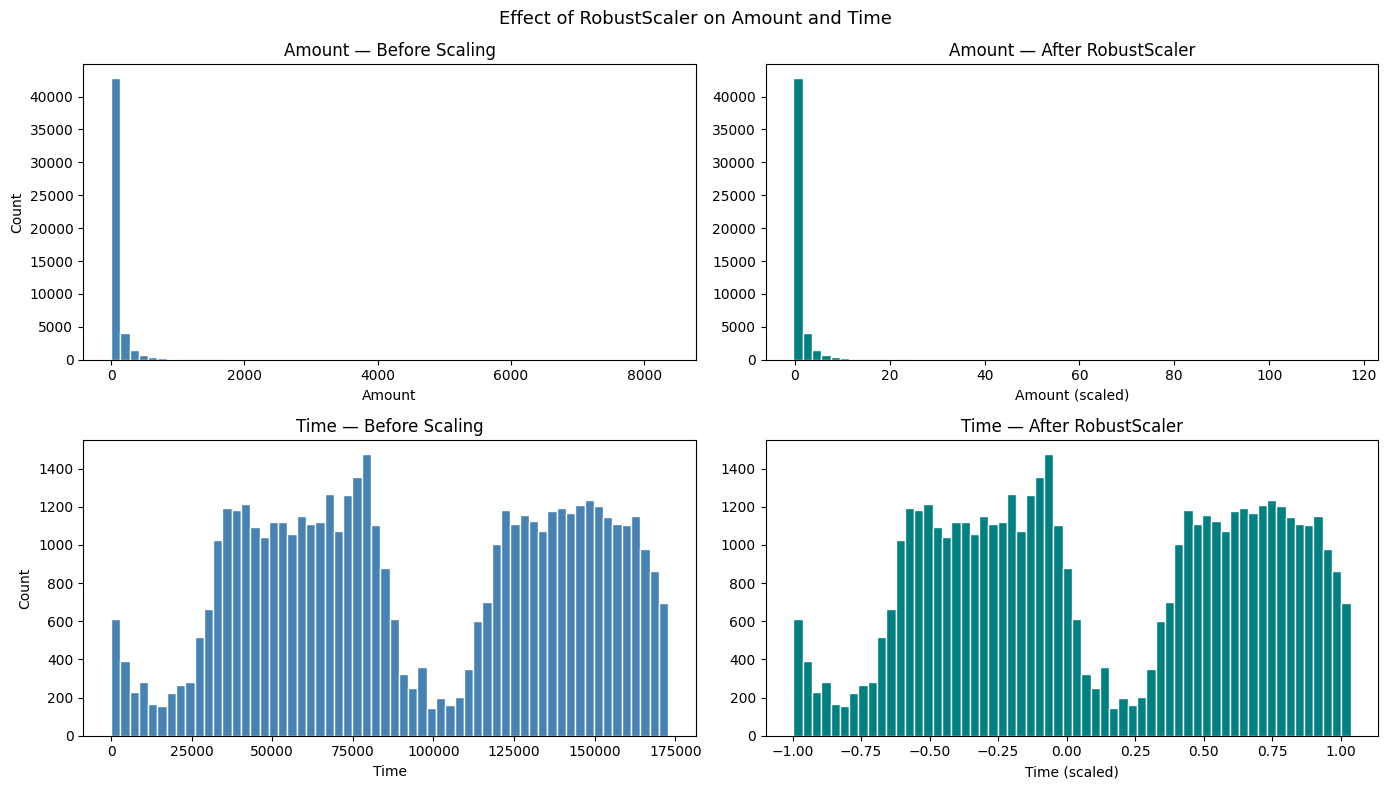

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(["Amount", "Time"]):
    axes[i, 0].hist(df[col], bins=60, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{col} — Before Scaling")
    axes[i, 0].set_xlabel(col); axes[i, 0].set_ylabel("Count")

    axes[i, 1].hist(df_clean[col], bins=60, color="teal", edgecolor="white")
    axes[i, 1].set_title(f"{col} — After RobustScaler")
    axes[i, 1].set_xlabel(f"{col} (scaled)")

plt.suptitle("Effect of RobustScaler on Amount and Time", fontsize=13)
plt.tight_layout(); plt.show()

**Verify & Save Cleaned Dataset**

In [7]:
assert df_clean.isnull().sum().sum() == 0, "Missing values found!"
assert df_clean["Class"].nunique() == 2, "Target should be binary!"

print(f"Final dataset shape  : {df_clean.shape}")
print(f"Missing values       : {df_clean.isnull().sum().sum()}")
print(f"Class distribution   :")
print(df_clean["Class"].value_counts())
print(f"Fraud rate           : {df_clean['Class'].mean()*100:.4f}%")
df_clean.head()

Final dataset shape  : (50439, 31)
Missing values       : 0
Class distribution   :
Class
0    49966
1      473
Name: count, dtype: int64
Fraud rate           : 0.9378%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.212037,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,-0.258572,0
1,0.400096,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,-0.290894,0
2,-0.202048,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,-0.280916,0
3,-0.921194,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,-0.233699,0
4,0.884182,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,2.431282,0


In [8]:
out_path = "/content/drive/MyDrive/Project Datasets/Credit Card Fraud Dataset_cleaned.csv"
df_clean.to_csv(out_path, index=False)
print(f"Cleaned dataset saved to: {out_path}")

Cleaned dataset saved to: /content/drive/MyDrive/Project Datasets/Credit Card Fraud Dataset_cleaned.csv
